In [84]:
# imports
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
from scipy.stats import chi2_contingency
import re
from scipy.stats import f_oneway


# machine learning
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.ensemble import RandomForestRegressor
from sklearn.neighbors import KNeighborsRegressor
from sklearn.model_selection import GridSearchCV
from sklearn.metrics import root_mean_squared_error
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.linear_model import Ridge
from sklearn.pipeline import make_pipeline
from sklearn.dummy import DummyRegressor
from sklearn.metrics import mean_absolute_error
from sklearn.tree import DecisionTreeRegressor
from sklearn.metrics import classification_report, confusion_matrix
from sklearn.metrics import accuracy_score
from sklearn.linear_model import LogisticRegression
from sklearn.compose import ColumnTransformer
from sklearn.metrics import mean_absolute_percentage_error
from sklearn.ensemble import HistGradientBoostingRegressor
from sklearn.ensemble import HistGradientBoostingClassifier
from sklearn.calibration import CalibratedClassifierCV
from sklearn.metrics import brier_score_loss
from sklearn.calibration import calibration_curve

In [85]:
tsc = pd.read_csv("Tsc2-LE_data_exported_20251015.csv")
tsc.head()

,date,rat_name,rat_ID,DOB,Sex,weight,Genotype,HL_date,invalid,file_name,...,stim_type,analysis_type,complete_block_count,trial_count,hit_percent,FA_percent,UUID,block_size,line,genotype
0,20230117,GP5,161,20220206,Male,483.0,Tsc2_LE_Het,NaN,NaN,32kHz_5-65dB_50ms_4s,...,tone,Tone (Single),30.0,300,0.757143,0.044444,20230117112140_40.0530014187098_3.23855481992454,10,Tsc2,Het
1,20230117,GP6,162,20220206,Male,570.0,Tsc2_LE_WT,NaN,NaN,8kHz_30-90dB_50ms_4s,...,tone,Tone (Single),43.0,433,0.917492,0.223077,20230117112140_180.444997921586_2.7957715020537,10,Tsc2,WT
2,20230117,GP1,144,20220127,Male,558.0,Tsc2_LE_Het,NaN,NaN,4kHz_30-60dB_50ms_4s,...,tone,Tone (Single),45.0,453,0.852201,0.207407,20230117122835_82.660998031497_2.42393043181062,10,Tsc2,Het
3,20230117,GP2,150,20220127,Male,509.0,Tsc2_LE_WT,NaN,NaN,4kHz_30-90dB_50ms_4s,...,tone,Tone (Single),41.0,410,0.853659,0.227642,20230117122835_117.839000746608_2.72426594934181,10,Tsc2,WT
4,20230117,GP3,145,20220127,Male,636.0,Tsc2_LE_Het,NaN,NaN,8kHz_30-90dB_50ms_4s,...,tone,Tone (Single),45.0,459,0.825545,0.108696,20230117133538_98.7920008599758_1.44631039885978,10,Tsc2,Het


In [86]:
tsc.columns

Index(['date', 'rat_name', 'rat_ID', 'DOB', 'Sex', 'weight', 'Genotype',
       'HL_date', 'invalid', 'file_name', 'experiment', 'phase', 'task',
       'detail', 'stim_type', 'analysis_type', 'complete_block_count',
       'trial_count', 'hit_percent', 'FA_percent', 'UUID', 'block_size',
       'line', 'genotype'],
      dtype='object')

In [87]:
tsc.shape

(8328, 24)

In [88]:
tsc.isna().sum()

date                       0
rat_name                   0
rat_ID                     0
DOB                        0
Sex                        0
weight                     2
Genotype                   0
HL_date                 8328
invalid                 8328
file_name                  0
experiment                 0
phase                      0
task                       0
detail                  1192
stim_type                  0
analysis_type              0
complete_block_count       0
trial_count                0
hit_percent                0
FA_percent               377
UUID                       0
block_size                 0
line                       0
genotype                   0
dtype: int64

In [89]:
arvhive = pd.read_csv("FXS x TSC_archive.csv")
arvhive.head()

,Time_since_file_start_(s),Stim_ID,Trial_type,Attempts_to_complete,Response,Reaction_(s),Type,Stim Source,Freq (kHz),Inten (dB),Dur (ms),Nose Out TL (s),Time Out (s),Delay (s),Trial_number,Block_number,complete_block_number,UUID
0,76.545994,1,1,1,Hit,1.806355,1,BBN,0,60,300,2,0,0.392612,1,1,1.0,20241017112851_76.5459939837456_0.392612257771637
1,85.074996,1,1,1,Hit,0.060132,1,BBN,0,60,300,2,0,0.344607,2,1,1.0,20241017112851_76.5459939837456_0.392612257771637
2,109.837002,1,1,3,Hit,0.717941,1,BBN,0,60,300,2,0,0.330606,3,1,1.0,20241017112851_76.5459939837456_0.392612257771637
3,228.694998,1,1,1,Hit,0.301456,1,BBN,0,60,300,2,0,0.045595,4,1,1.0,20241017112851_76.5459939837456_0.392612257771637
4,269.197997,1,1,1,Miss,2.000000,1,BBN,0,60,300,2,0,0.124481,5,1,1.0,20241017112851_76.5459939837456_0.392612257771637


In [90]:
arvhive.columns

Index(['Time_since_file_start_(s)', 'Stim_ID', 'Trial_type',
       'Attempts_to_complete', 'Response', 'Reaction_(s)', 'Type',
       'Stim Source', 'Freq (kHz)', 'Inten (dB)', 'Dur (ms)',
       'Nose Out TL (s)', 'Time Out (s)', 'Delay (s)', 'Trial_number',
       'Block_number', 'complete_block_number', 'UUID'],
      dtype='object')

In [91]:
tsc["Genotype"].value_counts()

Genotype
Tsc2_LE_WT     4324
Tsc2_LE_Het    4004
Name: count, dtype: int64

In [92]:
tsc["Sex"].value_counts()

Sex
Male      4773
Female    3555
Name: count, dtype: int64

In [93]:
# Drop unnecessary columns for this analysis
cols_to_keep = ['rat_ID', 'Sex', 'Genotype', 'hit_percent', 'FA_percent', 'trial_count', 'complete_block_count','weight','trial_count']
tsc = tsc[cols_to_keep]

# Drop rows missing essential performance data
tsc = tsc.dropna(subset=['hit_percent', 'FA_percent', 'Sex', 'Genotype'])
tsc.isna().sum()

rat_ID                  0
Sex                     0
Genotype                0
hit_percent             0
FA_percent              0
trial_count             0
complete_block_count    0
weight                  2
trial_count             0
dtype: int64

In [94]:
# Count per group
print(tsc.groupby(['Genotype', 'Sex']).size())

# Summary stats for performance
desc = tsc.groupby(['Genotype', 'Sex'])[['hit_percent', 'FA_percent']].describe()
desc

Genotype     Sex   
Tsc2_LE_Het  Female    1587
             Male      2230
Tsc2_LE_WT   Female    1800
             Male      2334
dtype: int64


hit_percent                                          \
                         count      mean       std       min       25%   
Genotype    Sex                                                          
Tsc2_LE_Het Female      1587.0  0.905397  0.078236  0.546980  0.860215   
            Male        2230.0  0.901753  0.080553  0.554217  0.851852   
Tsc2_LE_WT  Female      1800.0  0.919782  0.071347  0.500000  0.879346   
            Male        2334.0  0.907687  0.073421  0.250000  0.865768   

                                            FA_percent                      \
                         50%       75%  max      count      mean       std   
Genotype    Sex                                                              
Tsc2_LE_Het Female  0.920930  0.971429  1.0     1587.0  0.204059  0.167292   
            Male    0.918270  0.970744  1.0     2230.0  0.198334  0.191949   
Tsc2_LE_WT  Female  0.936045  0.980424  1.0     1800.0  0.226601  0.205459   
            Male    0.916984  0.969132  1.0     2334.0  0.233431  0.201191   

                                                            
                    min       25%       50%       75%  max  
Genotype    Sex                                             
Tsc2_LE_Het Female  0.0  0.100000  0.162791  0.247168  1.0  
            Male    0.0  0.068182  0.140741  0.250000  1.0  
Tsc2_LE_WT  Female  0.0  0.090909  0.162331  0.277778  1.0  
            Male    0.0  0.102740  0.167226  0.294001  1.0

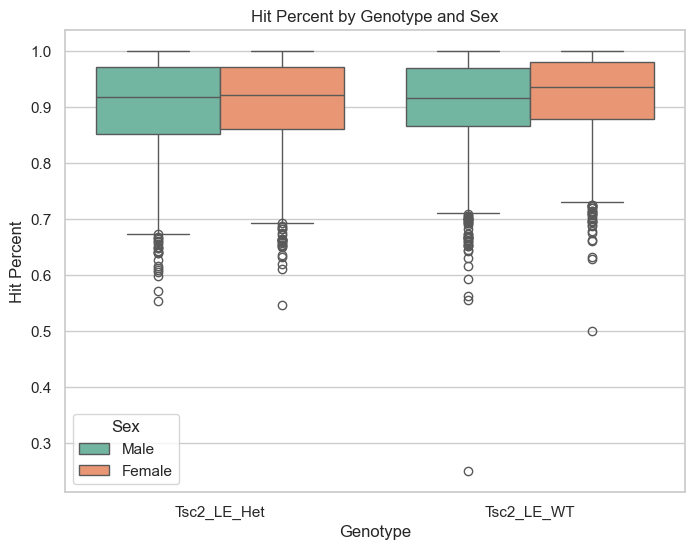

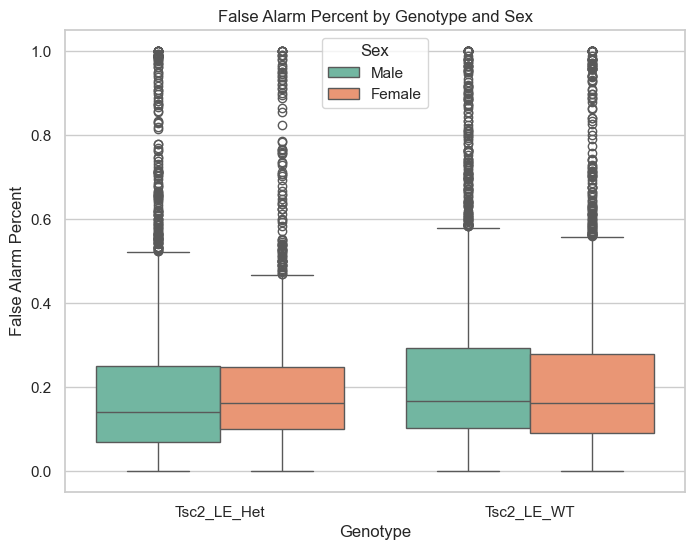

In [95]:
import seaborn as sns
import matplotlib.pyplot as plt

sns.set(style="whitegrid")

# Boxplot for Hit Percent
plt.figure(figsize=(8,6))
sns.boxplot(data=tsc, x='Genotype', y='hit_percent', hue='Sex', palette='Set2')
plt.title('Hit Percent by Genotype and Sex')
plt.ylabel('Hit Percent')
plt.show()

# Boxplot for False Alarm Percent
plt.figure(figsize=(8,6))
sns.boxplot(data=tsc, x='Genotype', y='FA_percent', hue='Sex', palette='Set2')
plt.title('False Alarm Percent by Genotype and Sex')
plt.ylabel('False Alarm Percent')
plt.show()

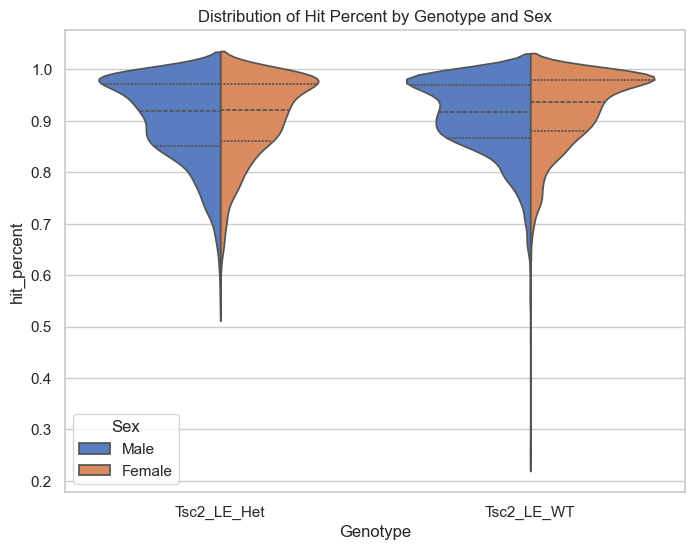

In [96]:
plt.figure(figsize=(8,6))
sns.violinplot(data=tsc, x='Genotype', y='hit_percent', hue='Sex', split=True, inner='quartile', palette='muted')
plt.title('Distribution of Hit Percent by Genotype and Sex')
plt.show()

<Figure size 800x600 with 0 Axes>

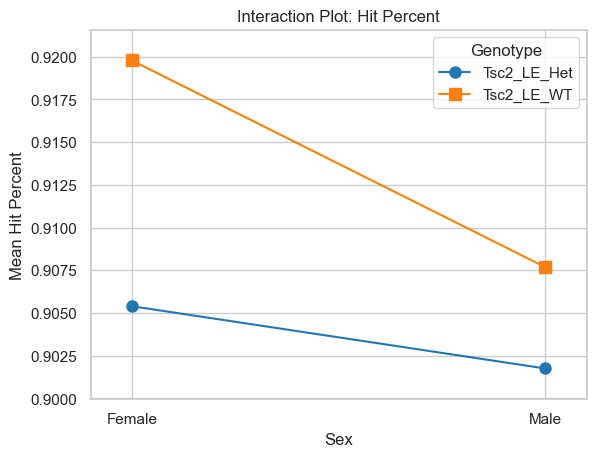

In [97]:
import statsmodels.api as sm
from statsmodels.graphics.factorplots import interaction_plot

plt.figure(figsize=(8,6))
interaction_plot(tsc['Sex'], tsc['Genotype'], tsc['hit_percent'],
                 colors=['#1f77b4', '#ff7f0e'], markers=['o','s'], ms=8)
plt.title('Interaction Plot: Hit Percent')
plt.ylabel('Mean Hit Percent')
plt.show()

**Statistical Test**

In [98]:
import statsmodels.formula.api as smf

# Convert categorical variables to categorical type
tsc['Sex'] = tsc['Sex'].astype('category')
tsc['Genotype'] = tsc['Genotype'].astype('category')

# ANOVA model
model_hit = smf.ols('hit_percent ~ C(Sex) * C(Genotype)', data=tsc).fit()
anova_hit = sm.stats.anova_lm(model_hit, typ=2)
print(anova_hit)

                       sum_sq      df          F        PR(>F)
C(Sex)               0.126354     1.0  21.873945  2.959677e-06
C(Genotype)          0.180046     1.0  31.168884  2.443197e-08
C(Sex):C(Genotype)   0.034637     1.0   5.996214  1.435807e-02
Residual            45.905458  7947.0        NaN           NaN


| Effect         | F     | p-value  | Interpretation                                                                          |
| -------------- | ----- | -------- | --------------------------------------------------------------------------------------- |
| Sex            | 21.87 | 2.96e-06 |  **Significant** main effect of Sex. Males and females differ in hit rates overall.    |
| Genotype       | 31.17 | 2.44e-08 |  **Significant** main effect of Genotype. WT and Het rats differ in hit rates overall. |
| Sex × Genotype | 5.99  | 0.014    |  **Significant interaction**: The gender difference depends on genotype.               |


In [99]:
model_fa = smf.ols('FA_percent ~ C(Sex) * C(Genotype)', data=tsc).fit()
anova_fa = sm.stats.anova_lm(model_fa, typ=2)
print(anova_fa)

                        sum_sq      df          F        PR(>F)
C(Sex)                0.001372     1.0   0.036727  8.480271e-01
C(Genotype)           1.756920     1.0  47.028564  7.519950e-12
C(Sex):C(Genotype)    0.076422     1.0   2.045637  1.526824e-01
Residual            296.888592  7947.0        NaN           NaN


| Effect         | F     | p-value | Interpretation                   |
| -------------- | ----- | ------- | -------------------------------- |
| Sex            | 0.037 | 0.848   |  No main effect of sex          |
| Genotype       | 47.03 | 7.5e-12 |  Strong main effect of genotype |
| Sex × Genotype | 2.05  | 0.153   |  No significant interaction     |

***Interpretation:***

Only genotype affects FA%, not sex.

WT and Het differ, but males and females don’t.

In [100]:
from statsmodels.stats.multicomp import pairwise_tukeyhsd

tukey = pairwise_tukeyhsd(endog=tsc['hit_percent'],
                          groups=tsc['Genotype'].astype(str) + "_" + tsc['Sex'].astype(str),
                          alpha=0.05)
print(tukey)

           Multiple Comparison of Means - Tukey HSD, FWER=0.05            
      group1             group2      meandiff p-adj   lower  upper  reject
--------------------------------------------------------------------------
Tsc2_LE_Het_Female  Tsc2_LE_Het_Male  -0.0036 0.4621 -0.0101 0.0028  False
Tsc2_LE_Het_Female Tsc2_LE_WT_Female   0.0144    0.0  0.0077 0.0211   True
Tsc2_LE_Het_Female   Tsc2_LE_WT_Male   0.0023 0.7909 -0.0041 0.0086  False
  Tsc2_LE_Het_Male Tsc2_LE_WT_Female    0.018    0.0  0.0118 0.0242   True
  Tsc2_LE_Het_Male   Tsc2_LE_WT_Male   0.0059 0.0418  0.0002 0.0117   True
 Tsc2_LE_WT_Female   Tsc2_LE_WT_Male  -0.0121    0.0 -0.0182 -0.006   True
--------------------------------------------------------------------------


***Tukey post-hoc summary:***

WT females have higher hit percent than WT males (p < 0.001).

Het males perform slightly worse than WT females (p < 0.001).

No strong difference between Het males vs females (ns).

***Interpretation:***

Sex and genotype both influence performance, and the gender difference is larger in WT rats (female > male).

The interaction means the sex effect is not consistent across genotypes.

C:\Users\LENOVO\AppData\Local\Temp\ipykernel_17392\790797950.py:3: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  summary = tsc.groupby(['Genotype', 'Sex']).agg(
C:\Users\LENOVO\AppData\Local\Temp\ipykernel_17392\790797950.py:11: FutureWarning: 

The `ci` parameter is deprecated. Use `errorbar=None` for the same effect.

  sns.barplot(data=summary, x='Genotype', y='mean_hit', hue='Sex', palette='Set2', ci=None)


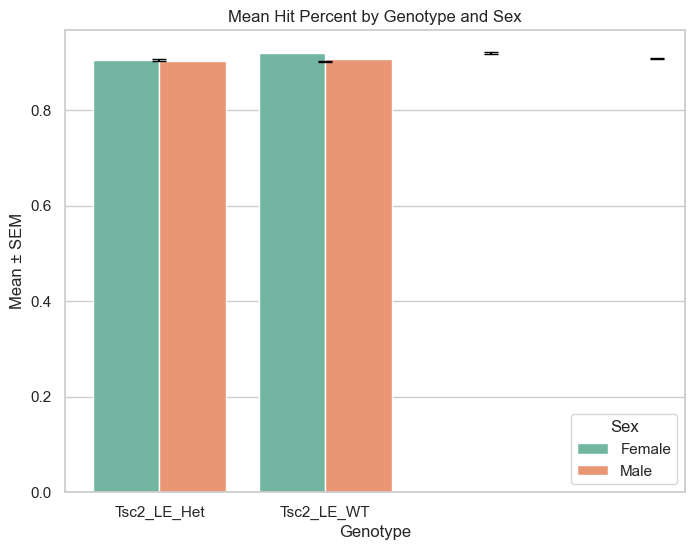

In [101]:
from scipy.stats import sem

summary = tsc.groupby(['Genotype', 'Sex']).agg(
    mean_hit=('hit_percent', 'mean'),
    sem_hit=('hit_percent', sem),
    mean_fa=('FA_percent', 'mean'),
    sem_fa=('FA_percent', sem)
).reset_index()

plt.figure(figsize=(8,6))
sns.barplot(data=summary, x='Genotype', y='mean_hit', hue='Sex', palette='Set2', ci=None)
plt.errorbar(x=np.arange(len(summary)), y=summary['mean_hit'], yerr=summary['sem_hit'], fmt='none', c='black', capsize=5)
plt.title('Mean Hit Percent by Genotype and Sex')
plt.ylabel('Mean ± SEM')
plt.show()

**Adding a Covariate (ANCOVA)**

Control for Weight

In [102]:
# Drop rows missing weight
tsc_ancova = tsc.dropna(subset=['weight'])

# ANCOVA for hit_percent controlling for weight
model_hit_ancova = smf.ols('hit_percent ~ C(Sex) * C(Genotype) + weight', data=tsc_ancova).fit()
anova_hit_ancova = sm.stats.anova_lm(model_hit_ancova, typ=2)
print(anova_hit_ancova)

                       sum_sq      df          F        PR(>F)
C(Sex)               0.029618     1.0   5.126840  2.358542e-02
C(Genotype)          0.185263     1.0  32.069219  1.539625e-08
C(Sex):C(Genotype)   0.035057     1.0   6.068453  1.378279e-02
weight               0.006200     1.0   1.073233  3.002479e-01
Residual            45.892219  7944.0        NaN           NaN


| Effect                 | F     | p-value | Interpretation                                                                           |
| ---------------------- | ----- | ------- | ---------------------------------------------------------------------------------------- |
| **C(Sex)**             | 5.13  | 0.0236  |  Still **significant**: Sex has an effect on hit rate even after accounting for weight. |
| **C(Genotype)**        | 32.07 | 1.5e-08 |  Strong main effect of Genotype: WT vs Het differ significantly in hit percent.         |
| **C(Sex):C(Genotype)** | 6.07  | 0.0138  |  Significant interaction: The sex difference **depends on genotype**.                   |
| **Weight (covariate)** | 1.07  | 0.300   |  Not significant: Weight doesn’t explain much variance in hit percent.                  |


In [103]:
model_hit_ancova2 = smf.ols('hit_percent ~ C(Sex) * C(Genotype) + trial_count', data=tsc).fit()
anova_hit_ancova2 = sm.stats.anova_lm(model_hit_ancova2, typ=2)
print(anova_hit_ancova2)

                       sum_sq      df          F        PR(>F)
C(Sex)               0.000794     1.0   0.138693  7.095938e-01
C(Genotype)          0.141943     1.0  24.788724  6.531686e-07
C(Sex):C(Genotype)   0.071305     1.0  12.452639  4.197616e-04
trial_count          0.811648     2.0  70.872579  4.478514e-17
Residual            45.499634  7946.0        NaN           NaN


c:\Users\LENOVO\anaconda3\Lib\site-packages\statsmodels\base\model.py:1894: ValueWarning: covariance of constraints does not have full rank. The number of constraints is 2, but rank is 1
  warnings.warn('covariance of constraints does not have full '


**Hit rate** = proportion of correct detections (signal present → response)

**False alarm rate (FA%)** = proportion of incorrect detections (signal absent → response)

d′ (d-prime) measures sensitivity — the subject’s ability to distinguish signal from noise, independently of response bias.
It’s often more meaningful than raw hit/FA percentages.

The formula for d′ is:
d'= Z(hit rate)-Z(FA rate)
where Z is the inverse of the standard normal CDF (scipy.stats.norm.ppf).

In [104]:
from scipy.stats import norm

def compute_dprime(hit_rate, fa_rate):
    # Convert to proportions
    h = hit_rate / 100
    f = fa_rate / 100
    
    # Correction for extreme values
    if h == 1: h = 1 - 1/(2*len(tsc))
    if h == 0: h = 1/(2*len(tsc))
    if f == 1: f = 1 - 1/(2*len(tsc))
    if f == 0: f = 1/(2*len(tsc))
    
    # Compute d'
    return norm.ppf(h) - norm.ppf(f)

tsc['dprime'] = tsc.apply(lambda x: compute_dprime(x['hit_percent'], x['FA_percent']), axis=1)
tsc.head()


,rat_ID,Sex,Genotype,hit_percent,FA_percent,trial_count,complete_block_count,weight,trial_count,dprime
0,161,Male,Tsc2_LE_Het,0.757143,0.044444,300,30.0,483.0,300,0.894576
1,162,Male,Tsc2_LE_WT,0.917492,0.223077,433,43.0,570.0,433,0.485058
2,144,Male,Tsc2_LE_Het,0.852201,0.207407,453,45.0,558.0,453,0.480914
3,150,Male,Tsc2_LE_WT,0.853659,0.227642,410,41.0,509.0,410,0.451950
4,145,Male,Tsc2_LE_Het,0.825545,0.108696,459,45.0,636.0,459,0.667961


Sensitivity differs by Sex and Genotype?

In [105]:
# Two-way ANOVA on d'
model_dprime = smf.ols('dprime ~ C(Sex) * C(Genotype)', data=tsc).fit()
anova_dprime = sm.stats.anova_lm(model_dprime, typ=2)
print(anova_dprime)

# ANCOVA version controlling for weight
model_dprime_ancova = smf.ols('dprime ~ C(Sex) * C(Genotype) + weight', data=tsc).fit()
anova_dprime_ancova = sm.stats.anova_lm(model_dprime_ancova, typ=2)
print(anova_dprime_ancova)

                        sum_sq      df          F        PR(>F)
C(Sex)                0.290436     1.0   4.135754  4.201952e-02
C(Genotype)           4.114507     1.0  58.589865  2.170373e-14
C(Sex):C(Genotype)    2.700583     1.0  38.455834  5.880550e-10
Residual            558.082632  7947.0        NaN           NaN
                        sum_sq      df           F        PR(>F)
C(Sex)                6.733282     1.0   97.308580  8.020855e-23
C(Genotype)           2.765154     1.0   39.961670  2.729754e-10
C(Sex):C(Genotype)    2.837285     1.0   41.004104  1.605437e-10
weight                8.316358     1.0  120.187010  9.096944e-28
Residual            549.686260  7944.0         NaN           NaN


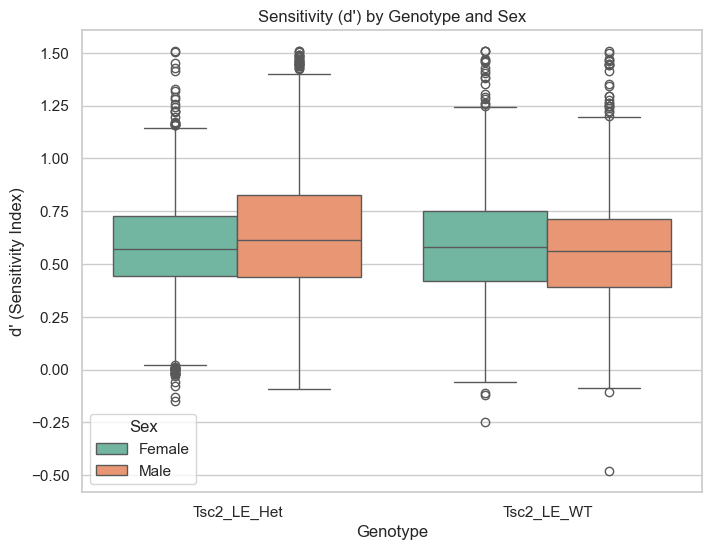

In [106]:
plt.figure(figsize=(8,6))
sns.boxplot(data=tsc, x='Genotype', y='dprime', hue='Sex', palette='Set2')
plt.title("Sensitivity (d') by Genotype and Sex")
plt.ylabel("d' (Sensitivity Index)")
plt.show()

**Pipline**

In [56]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats
import statsmodels.api as sm
from statsmodels.formula.api import glm
from statsmodels.genmod.families import Binomial, NegativeBinomial
from statsmodels.genmod.generalized_estimating_equations import GEE
from statsmodels.genmod.cov_struct import Exchangeable

In [57]:
def star_from_p(p):
    """Return text annotation for p-value."""
    if p < 0.0001:
        return '****'
    if p < 0.001:
        return '***'
    if p < 0.01:
        return '**'
    if p < 0.05:
        return '*'
    return 'ns'

def safe_div(a, b):
    a = np.asarray(a, dtype=float)
    b = np.asarray(b, dtype=float)
    with np.errstate(divide='ignore', invalid='ignore'):
        res = np.where(b == 0, np.nan, a / b)
    return res

In [58]:
def load_files(trial_csv_path, info_csv_path):
    trials = pd.read_csv(trial_csv_path)
    info = pd.read_csv(info_csv_path)
    # normalize UUIDs if present
    if 'UUID' in trials.columns:
        trials['UUID'] = trials['UUID'].astype(str).str.strip()
    if 'UUID' in info.columns:
        info['UUID'] = info['UUID'].astype(str).str.strip()
    return trials, info

In [59]:
def merge_and_clean(trials, info, keep_cols_info=None):
    # Standardize column names for delays and attempts
    rename_map = {}
    if 'Delay (s)' in trials.columns and 'Delay' not in trials.columns:
        rename_map['Delay (s)'] = 'Delay'
    if 'Attempts_to_complete' not in trials.columns and 'Attempts' in trials.columns:
        rename_map['Attempts'] = 'Attempts_to_complete'
    trials = trials.rename(columns=rename_map)

    # Merge on UUID if available else on rat_ID + date (try UUID first)
    if 'UUID' in trials.columns and 'UUID' in info.columns:
        merged = pd.merge(trials, info, on='UUID', how='left', suffixes=('', '_info'))
    else:
        # fallback: try merge on rat_ID + date
        if 'rat_ID' in trials.columns and 'rat_ID' in info.columns and 'date' in trials.columns:
            trials['date'] = pd.to_datetime(trials['date'], errors='coerce')
            info['date'] = pd.to_datetime(info['date'], errors='coerce')
            merged = pd.merge(trials, info, on=['rat_ID','date'], how='left', suffixes=('', '_info'))
        else:
            merged = trials.copy()

    # unify date columns
    # prefer a 'date' column in merged, else extract from any candidate
    if 'date' not in merged.columns:
        for c in ['Date', 'session_date', 'session_datetime', 'date_info']:
            if c in merged.columns:
                merged['date'] = pd.to_datetime(merged[c], errors='coerce')
                break
    else:
        merged['date'] = pd.to_datetime(merged['date'], errors='coerce')

    # ensure numeric columns
    for col in ['Delay', 'Attempts_to_complete', 'Reaction_(s)', 'weight', 'hit_percent', 'FA_percent']:
        if col in merged.columns:
            merged[col] = pd.to_numeric(merged[col], errors='coerce')

    # drop rows with impossible attempts or missing delays
    merged = merged[merged['Attempts_to_complete'].notna()]
    merged = merged[merged['Delay'].notna()]

    return merged

In [60]:
def engineer_features(df):
    df = df.copy()
    # Define patience binary and counts
    df['one_attempt'] = (df['Attempts_to_complete'] == 1).astype(int)
    df['more_than_one_attempt'] = (df['Attempts_to_complete'] > 1).astype(int)
    # Use consistent rat identifier
    if 'rat_ID' not in df.columns and 'rat_id' in df.columns:
        df['rat_ID'] = df['rat_id']
    # session-level aggregations
    session_cols = ['UUID','rat_ID','date','Genotype','Sex','file_name']
    # compute session-level success proportion
    session = df.groupby(['UUID','rat_ID','date','Genotype','Sex']).agg(
        total_trials=('one_attempt','count'),
        trials_one_attempt=('one_attempt','sum'),
        mean_attempts=('Attempts_to_complete','mean'),
        median_delay=('Delay','median'),
        mean_delay=('Delay','mean'),
        mean_FA_percent=('FA_percent','mean')
    ).reset_index()
    session['prop_one_attempt'] = safe_div(session['trials_one_attempt'], session['total_trials'])

    # rat-level rolling weight change
    if 'weight' in df.columns and 'date' in df.columns:
        df = df.sort_values(['rat_ID','date'])
        # session weight by rat-date (if multiple trials per session they share weight)
        weight_session = df[['rat_ID','date','weight']].drop_duplicates()
        weight_session['weight_prev1'] = weight_session.groupby('rat_ID')['weight'].shift(1)
        weight_session['weight_change_1d'] = weight_session['weight'] - weight_session['weight_prev1']
        # define a 4-day run-of-loss flag
        weight_session['weight_loss_flag_4d'] = weight_session.groupby('rat_ID')['weight_change_1d'].apply(
            lambda s: s.rolling(4, min_periods=1).apply(lambda x: (x<0).all()).fillna(0)
        )
        session = pd.merge(session, weight_session[['rat_ID','date','weight','weight_change_1d','weight_loss_flag_4d']],
                           on=['rat_ID','date'], how='left')

    # compute trial-level SDT counts if we can
    # we need trial_type (go/no-go) and Response to identify hits/FAs
    # compute trial-level SDT counts if we can
    df['Trial_type_norm'] = df.get('Trial_type', df.get('Trial Type', np.nan))
    df['Response_norm'] = df.get('Response', np.nan)
    df['is_go'] = df['Trial_type_norm'].astype(str).str.lower().str.contains('go')
    df['is_hit'] = ((df['is_go']) & 
                    (~df['Response_norm'].isna()) &
                    (df['Response_norm'].astype(str).str.lower().str.contains('hit|resp|out|yes|1'))).astype(int)
    df['is_fa'] = ((~df['is_go']) &
                   (~df['Response_norm'].isna()) &
                   (df['Response_norm'].astype(str).str.lower().str.contains('hit|resp|out|yes|1'))).astype(int)

# session-level SDT by UUID
    sdt = df.groupby(['UUID','rat_ID','date','Genotype','Sex']).agg(
        go_trials=('is_go','sum'),
        hits=('is_hit','sum'),
        fas=('is_fa','sum')
        ).reset_index()

# compute no_go_trials separately
    no_go_counts = df.groupby('UUID')['is_go'].apply(lambda x: (~x).sum()).rename('no_go_trials')

# join and compute rates
    sdt = sdt.set_index('UUID').join(no_go_counts).reset_index()

    def ll_correct(hit, go, fa, nogo):
        hr = (hit + 0.5) / (go + 1.0) if go > 0 else np.nan
        far = (fa + 0.5) / (nogo + 1.0) if nogo > 0 else np.nan
        return hr, far

    def z(x):
        return stats.norm.ppf(np.clip(x, 1e-6, 1-1e-6))

    sdt[['hit_rate','fa_rate']] = sdt.apply(
        lambda r: pd.Series(ll_correct(r['hits'], r['go_trials'], r['fas'], r['no_go_trials'])), axis=1
    )
    sdt['dprime'] = sdt.apply(
        lambda r: z(r['hit_rate']) - z(r['fa_rate'])
        if pd.notnull(r['hit_rate']) and pd.notnull(r['fa_rate'])
        else np.nan,
        axis=1
    )

In [61]:
def contingency_by_genotype(session_df, delay_cut=2.5):
    """Build genotype x one_attempt contingency for trials with Delay >= delay_cut."""
    # Need trial-level or session-level with per-trial counts; we'll re-aggregate from trial df if given
    raise NotImplementedError("Use trial-level aggregation for chi-square: see example below.")

# Example: chi-square aggregated from trial-level dataframe
def chi_square_genotype(trials_df, genotype_col='Genotype', delay_cut=2.5):
    df = trials_df[trials_df['Delay'] >= delay_cut]
    # aggregate counts of one_attempt per genotype
    tab = df.groupby(genotype_col).agg(one_attempts=('one_attempt','sum'), non_one=('one_attempt','count'))
    # non_one is total trials; adjust
    tab['total'] = df.groupby(genotype_col)['one_attempt'].count()
    tab['not_one'] = tab['total'] - tab['one_attempts']
    cont = tab[['one_attempts','not_one']].astype(int).values
    # use chi2_contingency on the matrix where rows = genotype, cols = success/failure
    from scipy.stats import chi2_contingency
    chi2, p, dof, expected = chi2_contingency(cont)
    # compute cramers V
    n = cont.sum()
    phi2 = chi2 / n
    r,k = cont.shape
    cramers_v = np.sqrt(phi2 / min(r-1, k-1))
    return {'chi2':chi2, 'p':p, 'dof':dof, 'expected':expected, 'cramers_v':cramers_v, 'contingency_table':cont, 'genotypes':tab.index.tolist()}

In [62]:
def gee_logistic_trial_level(trials_df, formula=None, group_col='rat_ID'):
    """
    trials_df must be trial-level with a binary 'one_attempt' column (0/1).
    We'll use GEE with Binomial family and Exchangeable covariance by rat.
    """
    if formula is None:
        formula = 'one_attempt ~ C(Genotype) * C(Sex) + Delay'
    # prepare data: drop NA
    model_df = trials_df.dropna(subset=['one_attempt','Genotype','Sex','Delay'])
    # convert categorical
    model_df['Genotype'] = model_df['Genotype'].astype('category')
    model_df['Sex'] = model_df['Sex'].astype('category')
    model_df = model_df.reset_index(drop=True)
    # design matrices with patsy
    import patsy
    y, X = patsy.dmatrices(formula, model_df, return_type='dataframe')
    gee_mod = GEE(y, X, groups=model_df[group_col], family=Binomial(), cov_struct=Exchangeable())
    gee_res = gee_mod.fit()
    return gee_res, model_df, X.columns

In [63]:
def negative_binomial_attempts(trials_df, formula=None):
    """
    Model Attempts_to_complete (counts) ~ predictors using NB in statsmodels GLM.
    """
    if formula is None:
        formula = 'Attempts_to_complete ~ C(Genotype) * C(Sex) + Delay + C(file_name)'
    # drop NA
    model_df = trials_df.dropna(subset=['Attempts_to_complete','Genotype','Sex','Delay'])
    nb_model = glm(formula=formula, data=model_df, family=NegativeBinomial())
    nb_res = nb_model.fit()
    return nb_res

In [64]:
def plot_prop_by_genotype(session_df, annotate_p=True, savepath=None):
    plt.figure(figsize=(7,5))
    sns.boxplot(x='Genotype', y='prop_one_attempt', data=session_df, showcaps=True, showfliers=False)
    sns.swarmplot(x='Genotype', y='prop_one_attempt', data=session_df, color='k', alpha=0.6, size=4)
    plt.ylabel('Proportion of Trials Completed in One Attempt')
    plt.title('Per-session proportion of 1-attempt trials by Genotype')
    # optional statistical annotation: pairwise t-tests
    if annotate_p:
        genotypes = session_df['Genotype'].dropna().unique().tolist()
        pairs = []
        for i in range(len(genotypes)):
            for j in range(i+1, len(genotypes)):
                pairs.append((genotypes[i], genotypes[j]))
        y_max = session_df['prop_one_attempt'].max()
        y = y_max + 0.05
        for a,b in pairs:
            da = session_df.loc[session_df['Genotype']==a,'prop_one_attempt'].dropna()
            db = session_df.loc[session_df['Genotype']==b,'prop_one_attempt'].dropna()
            if len(da)>2 and len(db)>2:
                t,p = stats.ttest_ind(da, db, equal_var=False)
                txt = star_from_p(p)
                plt.text((genotypes.index(a)+genotypes.index(b))/2, y, txt, ha='center')
                y += 0.04
    if savepath:
        plt.savefig(savepath, bbox_inches='tight')
    plt.show()

def plot_logistic_fit(trials_df, genotype='Tsc2_Het', sex='M', ax=None):
    """
    Quick visualization: logistic fit probability of first-attempt success across Delay for a single genotype-sex group.
    """
    sub = trials_df[(trials_df['Genotype']==genotype) & (trials_df['Sex']==sex)]
    if sub.empty:
        print("No data for", genotype, sex)
        return
    # fit logistic regression (no clustering) for visualization
    import statsmodels.formula.api as smf
    mod = smf.logit('one_attempt ~ Delay', data=sub.dropna(subset=['one_attempt','Delay']))
    try:
        res = mod.fit(disp=False)
        delays = np.linspace(sub['Delay'].min(), sub['Delay'].max(), 80)
        Xpred = sm.add_constant(delays)
        preds = res.predict(pd.DataFrame({'Delay':delays}))
    except Exception as e:
        print("Logit failed:", e)
        preds = None
        delays = None

    if ax is None:
        fig, ax = plt.subplots(figsize=(6,4))
    sns.scatterplot(x='Delay', y='one_attempt', data=sub, alpha=0.2, ax=ax)
    if preds is not None:
        ax.plot(delays, preds, label=f'Logit fit ({genotype}, {sex})')
        ax.legend()
    ax.set_ylabel('First-attempt success (0/1)')
    ax.set_title(f'First-attempt success vs Delay: {genotype} {sex}')
    plt.show()

In [65]:
def run_pipeline(trial_csv_path, info_csv_path, delay_threshold=2.5, save_clean_path='cleaned_data.csv'):
    trials, info = load_files(trial_csv_path, info_csv_path)
    merged = merge_and_clean(trials, info)
    trials_feat, session_df, sdt = engineer_features(merged)
    # save cleaned
    trials_feat.to_csv(save_clean_path, index=False)
    print("Cleaned saved to:", save_clean_path)
    # Chi-square example
    chi = chi_square_genotype(trials_feat, genotype_col='Genotype', delay_cut=delay_threshold)
    print("Chi-square result:", chi['chi2'], "p:", chi['p'], "Cramer's V:", chi['cramers_v'])
    # GEE logistic
    gee_res, model_df, columns = gee_logistic_trial_level(trials_feat, formula='one_attempt ~ C(Genotype) * C(Sex) + Delay', group_col='rat_ID')
    print(gee_res.summary())
    # NB attempts
    try:
        nb_res = negative_binomial_attempts(trials_feat, formula='Attempts_to_complete ~ C(Genotype) * C(Sex) + Delay')
        print(nb_res.summary())
    except Exception as e:
        print("NB model failed:", e)
    # plots
    plot_prop_by_genotype(session_df, annotate_p=True)
    # example logistic fit plot for group combos
    for g in session_df['Genotype'].unique():
        for s in session_df['Sex'].unique():
            plot_logistic_fit(trials_feat, genotype=g, sex=s)
    return trials_feat, session_df, sdt, gee_res

In [66]:
# dprime boxplot
# plt.figure(figsize=(8,6))
# sns.boxplot(x='Genotype', y='dprime', data=sdt, hue='Sex')
# sns.swarmplot(x='Genotype', y='dprime', data=sdt, hue='Sex', dodge=True, color='k', alpha=0.6, size=3)
# plt.title("d' by Genotype and Sex")
# plt.ylabel("d'")
# plt.legend(title='Sex')
# plt.show()

In [ ]:
# 1. Load data
trials, info = load_files('FXS x TSC_archive.csv', 'Tsc2-LE_data_exported_20251015.csv')
print("Trials shape:", trials.shape)
print("Info shape:", info.shape)
display(trials.head())
display(info.head())

# 2. Merge and clean
merged = merge_and_clean(trials, info)
print("Merged shape:", merged.shape)
display(merged.head())

# 3. Feature engineering
trials_feat, session_df, sdt = engineer_features(merged)
print("Trials with features:", trials_feat.shape)
print("Session-level summary:", session_df.shape)
print("SDT summary:", sdt.shape)
display(session_df.head())
display(sdt.head())

# 4. Chi-square test
chi = chi_square_genotype(trials_feat, genotype_col='Genotype', delay_cut=2.5)
print("\nChi-square test results:")
print("Chi² =", chi['chi2'])
print("p =", chi['p'])
print("Cramér’s V =", chi['cramers_v'])
print("Expected frequencies:\n", chi['expected'])
print("Contingency table:\n", pd.DataFrame(
    chi['contingency_table'], 
    index=chi['genotypes'], 
    columns=['one_attempts', 'not_one']
))

# 5. GEE logistic regression
gee_res, model_df, columns = gee_logistic_trial_level(
    trials_feat, 
    formula='one_attempt ~ C(Genotype) * C(Sex) + Delay', 
    group_col='rat_ID'
)
print(gee_res.summary())

# 6. Negative Binomial model
nb_res = negative_binomial_attempts(trials_feat)
print(nb_res.summary())

# 7. Plot summaries
plot_prop_by_genotype(session_df, annotate_p=True)
plot_logistic_fit(trials_feat, genotype='Tsc2_Het', sex='M')

Trials shape: (760601, 18)
Info shape: (8328, 24)


,Time_since_file_start_(s),Stim_ID,Trial_type,Attempts_to_complete,Response,Reaction_(s),Type,Stim Source,Freq (kHz),Inten (dB),Dur (ms),Nose Out TL (s),Time Out (s),Delay (s),Trial_number,Block_number,complete_block_number,UUID
0,76.545994,1,1,1,Hit,1.806355,1,BBN,0,60,300,2,0,0.392612,1,1,1.0,20241017112851_76.5459939837456_0.392612257771637
1,85.074996,1,1,1,Hit,0.060132,1,BBN,0,60,300,2,0,0.344607,2,1,1.0,20241017112851_76.5459939837456_0.392612257771637
2,109.837002,1,1,3,Hit,0.717941,1,BBN,0,60,300,2,0,0.330606,3,1,1.0,20241017112851_76.5459939837456_0.392612257771637
3,228.694998,1,1,1,Hit,0.301456,1,BBN,0,60,300,2,0,0.045595,4,1,1.0,20241017112851_76.5459939837456_0.392612257771637
4,269.197997,1,1,1,Miss,2.000000,1,BBN,0,60,300,2,0,0.124481,5,1,1.0,20241017112851_76.5459939837456_0.392612257771637


,date,rat_name,rat_ID,DOB,Sex,weight,Genotype,HL_date,invalid,file_name,...,stim_type,analysis_type,complete_block_count,trial_count,hit_percent,FA_percent,UUID,block_size,line,genotype
0,20230117,GP5,161,20220206,Male,483.0,Tsc2_LE_Het,NaN,NaN,32kHz_5-65dB_50ms_4s,...,tone,Tone (Single),30.0,300,0.757143,0.044444,20230117112140_40.0530014187098_3.23855481992454,10,Tsc2,Het
1,20230117,GP6,162,20220206,Male,570.0,Tsc2_LE_WT,NaN,NaN,8kHz_30-90dB_50ms_4s,...,tone,Tone (Single),43.0,433,0.917492,0.223077,20230117112140_180.444997921586_2.7957715020537,10,Tsc2,WT
2,20230117,GP1,144,20220127,Male,558.0,Tsc2_LE_Het,NaN,NaN,4kHz_30-60dB_50ms_4s,...,tone,Tone (Single),45.0,453,0.852201,0.207407,20230117122835_82.660998031497_2.42393043181062,10,Tsc2,Het
3,20230117,GP2,150,20220127,Male,509.0,Tsc2_LE_WT,NaN,NaN,4kHz_30-90dB_50ms_4s,...,tone,Tone (Single),41.0,410,0.853659,0.227642,20230117122835_117.839000746608_2.72426594934181,10,Tsc2,WT
4,20230117,GP3,145,20220127,Male,636.0,Tsc2_LE_Het,NaN,NaN,8kHz_30-90dB_50ms_4s,...,tone,Tone (Single),45.0,459,0.825545,0.108696,20230117133538_98.7920008599758_1.44631039885978,10,Tsc2,Het


Merged shape: (760601, 41)


,Time_since_file_start_(s),Stim_ID,Trial_type,Attempts_to_complete,Response,Reaction_(s),Type,Stim Source,Freq (kHz),Inten (dB),...,detail,stim_type,analysis_type,complete_block_count,trial_count,hit_percent,FA_percent,block_size,line,genotype
0,76.545994,1,1,1,Hit,1.806355,1,BBN,0,60,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,85.074996,1,1,1,Hit,0.060132,1,BBN,0,60,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,109.837002,1,1,3,Hit,0.717941,1,BBN,0,60,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3,228.694998,1,1,1,Hit,0.301456,1,BBN,0,60,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
4,269.197997,1,1,1,Miss,2.000000,1,BBN,0,60,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


ValueError: Columns must be same length as key